# Merge Observational Data across Datasets

## Import and read VKEB

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.mast import Mast, Observations
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
import lightkurve as lk

%matplotlib inline

# plt.rcParams.update({
#     "figure.dpi": 300,
#     "savefig.dpi": 300
# })


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
keb = pd.read_csv(r'../data/kepler-eclipsing-binary-catalog.csv')
keb = keb.drop(columns='Unnamed: 11')
keb.columns


Index(['KIC', 'period', 'period_err', 'bjd0', 'bjd0_err', 'morph', 'GLon',
       'GLat', 'kmag', 'Teff', 'SC'],
      dtype='str')

In [3]:
keb


,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC
0,3863594,0.053268,0.0,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False
1,10417986,0.073731,0.0,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True
2,8912468,0.094838,0.0,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False
3,8758716,0.107205,0.0,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False
4,10855535,0.112782,0.0,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False
...,...,...,...,...,...,...,...,...,...,...,...
2915,9408440,989.985000,-1.0,55346.365980,0.096130,0.00,78.5607,12.2615,13.199,5688.0,False
2916,8054233,1058.000000,-1.0,54751.806288,0.968052,0.03,78.6142,7.7321,11.783,4733.0,False
2917,7672940,1064.270000,-1.0,54977.092960,0.089646,0.00,74.5296,14.6136,12.328,-1.0,False
2918,11961695,1082.815000,-1.0,54871.395674,0.211754,0.02,81.8628,15.9404,13.718,5768.0,False


In [4]:
keb.loc[0]


KIC            3863594
period        0.053268
period_err         0.0
bjd0           55000.0
bjd0_err      0.004327
morph             0.79
GLon              -1.0
GLat              -1.0
kmag              -1.0
Teff              -1.0
SC               False
Name: 0, dtype: object

### Sample querying with `MAST` and the `NasaExoplanetArchive` modules

In [ ]:
keplerObs = Observations.query_criteria(target_name='kplr299096355', obs_collection='Kepler')
keplerObs


In [ ]:
tbl = NasaExoplanetArchive.query_criteria(
        table="cumulative", 
        select="*",
        where="kepid = 11446443"
    )

tbl


In [ ]:
NasaExoplanetArchive.query_object("Kepler-16 b")


## Common records between MAST and VKEB

In [5]:
keb.head()


,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC
0,3863594,0.053268,0.0,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False
1,10417986,0.073731,0.0,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True
2,8912468,0.094838,0.0,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False
3,8758716,0.107205,0.0,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False
4,10855535,0.112782,0.0,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False


In [6]:
sampleIndex = 3
sampleKIC = int(keb.loc[sampleIndex]['KIC'])
sampleKIC


8758716

In [7]:
MASTSearch = lk.search_lightcurve(
    f"{sampleKIC}",
    mission="Kepler"
)

MASTSearch


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 00,2009,Kepler,1800,kplr008758716,0.0
1,Kepler Quarter 01,2009,Kepler,1800,kplr008758716,0.0
2,Kepler Quarter 02,2009,Kepler,1800,kplr008758716,0.0
3,Kepler Quarter 03,2009,Kepler,1800,kplr008758716,0.0
4,Kepler Quarter 04,2010,Kepler,1800,kplr008758716,0.0
5,Kepler Quarter 05,2010,Kepler,1800,kplr008758716,0.0
6,Kepler Quarter 06,2010,Kepler,1800,kplr008758716,0.0
7,Kepler Quarter 07,2010,Kepler,1800,kplr008758716,0.0
8,Kepler Quarter 08,2011,Kepler,1800,kplr008758716,0.0


In [8]:
MASTSearch[-1] # Returns the last known result


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter,2009,KBONUS-BKG,1765,Gaia DR3 2126448581812562176,0.0


In [9]:
klc = MASTSearch[-1].download()
klc


time,flux,flux_err,cadenceno,quarter,quality,sap_flux,sap_flux_err,psf_flat_flux,psf_flat_flux_err,sap_quality,flatten_mask
,electron / s,electron / s,,,,electron / s,electron / s,electron / s,electron / s,,
Time,float64,float64,int32,int64,int32,float64,float64,float64,float64,int32,int32
120.53887240588665,66160.7935553238,7.099977931598636,568,0,0,69339.14795386198,7.546190143943578,66131.025877419,7.278952826027979,0,0
120.55930685903877,64927.485656316494,7.046302044535194,569,0,0,68013.79384289047,7.490512185457998,64899.26494513814,7.213680358177233,0,0
120.57974121300504,65614.0288293275,7.071674370840961,570,0,0,68734.93993980272,7.519325963070089,65587.21453019974,7.221798209965687,0,0
120.60017576627433,65813.53529379326,7.077039377219566,571,0,0,68963.25285699003,7.528389438544015,65788.12510112609,7.220411088753844,0,0
120.62061021989211,64837.866573430074,7.034473705232127,572,0,0,67899.26510427134,7.483675911832912,64813.89786305376,7.165853234035474,0,0
120.64104457339272,66111.9282431975,7.085056923562557,573,0,0,69267.8226407872,7.537680072376976,66089.24231763108,7.20142317346986,0,0
120.6614790270105,65239.894777440015,7.0462049532283535,574,0,0,68335.31138493425,7.498906336245689,65218.58519444201,7.14869835840128,0,0
120.6819135802798,65210.15197905916,7.042674854101844,575,0,0,68306.82467954636,7.497094735555723,65190.141245272665,7.131237161401538,0,0


In [10]:
klc.filename


np.str_('/Users/wayfinder/.lightkurve/cache/mastDownload/HLSP/hlsp_kbonus-bkg_kepler_kepler_kic-008758716_kepler_v1.0/hlsp_kbonus-bkg_kepler_kepler_kic-008758716_kepler_v1.0_lc.fits')

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

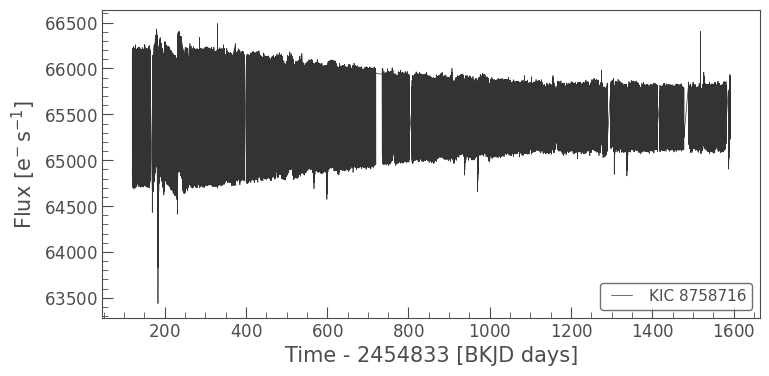

In [11]:
klc.plot()


The above graph plots the lightcurve as observed by PDCSAP (Pre-search Data Conditioning Simple Aperture Photometry) Flux. 

The SAP (Simple Aperture Photometry) light curve is calculated by summing together the brightness of pixels that fall within an aperture set by the Kepler mission. This is often referred to as the optimal aperture, but in spite of its name can sometimes be improved upon! Because the SAP light curve is a sum of the brightness in chosen pixels, it is still subject to systematic artifacts of the mission.

The PDCSAP light curve is subject to more treatment than the SAP light curve, and is specifically intended for detecting planets. The PDCSAP pipeline attempts to remove systematic artifacts while keeping planetary transits intact.

Below is what both LCs look like with different flux processing.

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized sap_flux'>

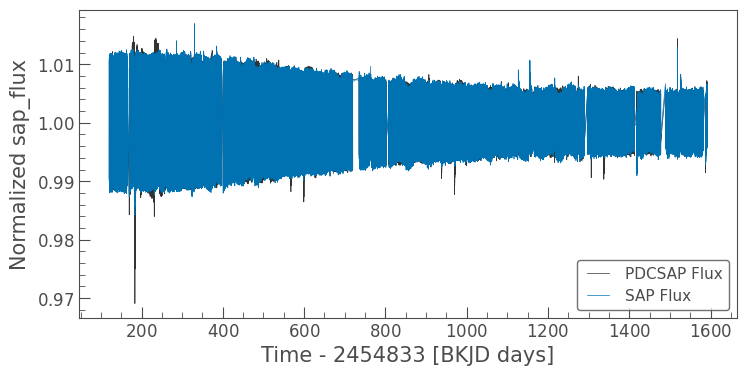

In [12]:
ax = klc.plot(column='flux', label='PDCSAP Flux', normalize=True)
klc.plot(column='sap_flux', label='SAP Flux', normalize=True, ax=ax)


*Note: The converted datetime for day 2454833 in UTC is 2012-03-13 12:00:00.000.*

## Data Review

The data for a single entity in both datasets is as follows. First the VKEB catalog's entry.

In [13]:
keb.loc[sampleIndex]


KIC                8758716
period            0.107205
period_err             0.0
bjd0          54953.672989
bjd0_err          0.006197
morph                  1.0
GLon               77.7478
GLat               11.6565
kmag                13.531
Teff                  -1.0
SC                   False
Name: 3, dtype: object

And it's latest flux entry on MAST.

In [ ]:
klc


time,flux,flux_err,cadenceno,quarter,quality,sap_flux,sap_flux_err,psf_flat_flux,psf_flat_flux_err,sap_quality,flatten_mask
,electron / s,electron / s,,,,electron / s,electron / s,electron / s,electron / s,,
Time,float64,float64,int32,int64,int32,float64,float64,float64,float64,int32,int32
120.53887240588665,66160.7935553238,7.099977931598636,568,0,0,69339.14795386198,7.546190143943578,66131.025877419,7.278952826027979,0,0
120.55930685903877,64927.485656316494,7.046302044535194,569,0,0,68013.79384289047,7.490512185457998,64899.26494513814,7.213680358177233,0,0
120.57974121300504,65614.0288293275,7.071674370840961,570,0,0,68734.93993980272,7.519325963070089,65587.21453019974,7.221798209965687,0,0
120.60017576627433,65813.53529379326,7.077039377219566,571,0,0,68963.25285699003,7.528389438544015,65788.12510112609,7.220411088753844,0,0
120.62061021989211,64837.866573430074,7.034473705232127,572,0,0,67899.26510427134,7.483675911832912,64813.89786305376,7.165853234035474,0,0
120.64104457339272,66111.9282431975,7.085056923562557,573,0,0,69267.8226407872,7.537680072376976,66089.24231763108,7.20142317346986,0,0
120.6614790270105,65239.894777440015,7.0462049532283535,574,0,0,68335.31138493425,7.498906336245689,65218.58519444201,7.14869835840128,0,0
120.6819135802798,65210.15197905916,7.042674854101844,575,0,0,68306.82467954636,7.497094735555723,65190.141245272665,7.131237161401538,0,0


And it's associated lightcurve.

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

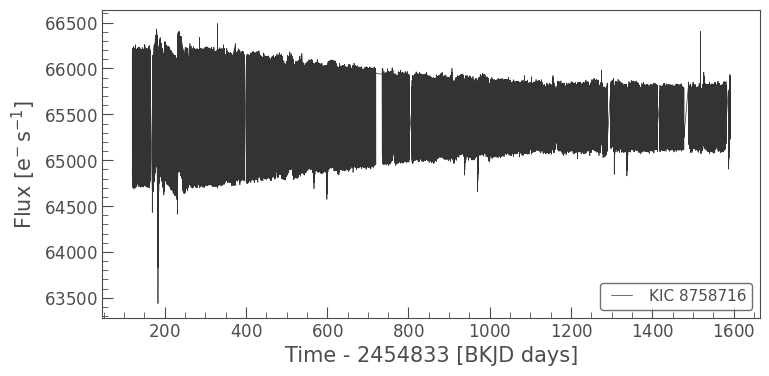

In [ ]:
klc.plot()
